In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

true_df["label"] = 1   # Real News
fake_df["label"] = 0   # Fake News

df = pd.concat([true_df, fake_df], axis=0)

df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Trump's call for probe of voter fraud sparks b...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"January 25, 2017",1
1,Debate stifled in Cambodia as crackdown spread...,"PHNOM PENH (Reuters) - We speak our mind , sa...",worldnews,"November 24, 2017",1
2,WATCH: Hitler EXPLODES At Trump Campaign In H...,As white supremacists whine about Donald Trump...,News,"August 28, 2016",0
3,Iraqi soldiers join Turkish exercises near sha...,"HABUR, Turkey (Reuters) - Iraqi soldiers joine...",worldnews,"September 26, 2017",1
4,Factbox: Trump on Twitter (Oct 24) - Bob Corke...,The following statements were posted to the ve...,politicsNews,"October 24, 2017",1


In [3]:
print(df.shape)
print(df.columns)

df["label"].value_counts()

(44898, 5)
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


label
0    23481
1    21417
Name: count, dtype: int64

In [ ]:
df["content"] = df["title"] + " " + df["text"]

data = df[["content", "label"]]

data.head()

,content,label
0,Trump's call for probe of voter fraud sparks b...,1
1,Debate stifled in Cambodia as crackdown spread...,1
2,WATCH: Hitler EXPLODES At Trump Campaign In H...,0
3,Iraqi soldiers join Turkish exercises near sha...,1
4,Factbox: Trump on Twitter (Oct 24) - Bob Corke...,1


In [5]:
X = data["content"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [18]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [8]:
y_pred = model.predict(X_test_vec)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9379732739420935

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4689
           1       0.94      0.93      0.93      4291

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



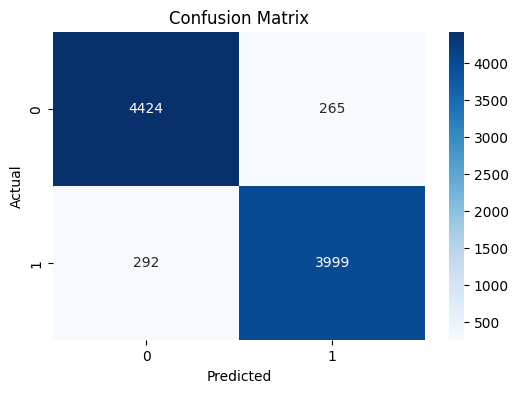

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
def predict_news(news):
    news_vec = vectorizer.transform([news])
    prediction = model.predict(news_vec)
    
    if prediction[0] == 1:
        return "Real News"
    else:
        return "Fake News"

# Example
print(predict_news(" Fresh Off The Golf Course, Trump Lashes Out At FBI Deputy Director And James Comey"))

Fake News
